# Maximum likelihood estimators for truncated power laws

The slope of power law-distributed data samples, where $f(x)\propto x^a$, is often determined by using histograms. This leads to the so-called binning bias. This bias can be avoided by methods that don't rely on binning such as **maximum likelihood estimators (MLEs)**. MLEs have been shown to outperform linear or logarithmic binning in estimating power law exponents regarding variance and bias ([White et al. 2008](https://doi.org/10.1890/07-1288.1)).

Maximum likelihood estimators are used to determine the most likely model parameters from a set of data, given an assumed model for the data distribution.\
Given a set of data, the MLE returns an estimate (or best guess) of the assumed models' parameters, that provides the best fit to the data.\
The following explanations of MLEs were written with the help of the book of [Lehmann and Casella (1998)](https://link.springer.com/book/10.1007/b98854) and an MLE introduction by statistician Sherry Towers (to be found under this [link](https://sherrytowers.com/mle_introduction.pdf)), who used the books of [Long (1997)](https://uk.sagepub.com/en-gb/eur/regression-models-for-categorical-and-limited-dependent-variables/book6071) and [King (1998)](https://press.umich.edu/Books/U/Unifying-Political-Methodology).

Within this notebook, a pure power law MLE and two different MLEs for truncated power laws are tested on a sample of stellar masses, where the goal is to find a function that can approximate the high-end downturn well, in order to get a good estimate of the distributions power law slope.

In the context of astrophysics, the provided MLEs may be useful to determine analytical approximations for ECMFs, but especially for composite IMFs and IGIMFs.\
For readers unfamilar with those terms, I refer to my other repository on the IGIMF theory, *IGIMF_theory_Codes*.

## What MLEs do and how they work

Maximum likelihood estimation has the same goal as regression models:\
It is a method to estimate model parameters from a set of data points in order to describe the form of the data distribution by an analytical function.

As a way to determine the best fit, the goal is to find the maximum of the **likelihood function**.\
Again, the equivalent in e.g. linear regression to this is the use of the least square method. The model with the the highest, aka maximum, likelihood is the most probable to have produced the observed data.

### Probability vs. Likelihood

Assume that we have a model, e.g. a function we try to fit on the data, that depends on a set of model parameters $\theta=\{\theta_1, \theta_2, ...\}$ and a single data point $x$.\
(Note that $\theta$ could also be just a single parameter)\
Then we can distinguish between probability and likelihood in the following way.

**Probability:**
- Answers the question: Given the model parameter/s $\theta$, what is the chance of seeing some data point with value $x$ under this specific model?
- The model parameter/s is/are fixed, the data point is the variable.

**Likelihood (also, likelihood function):**
- Answers the question: Given a data point with value $x$, what is the chance of seeing this specific data point depending on the model parameter/s $\theta$?
- The data point is fixed, the model parameter/s is/are the variable/s.

The probability $p(x|\theta)$ and likelihood $\mathcal{L}(\theta|x)$ for a single point and a given model have therefore the same value, but the interpretation is different.\
This also means, one can find the likelihood function via the probability density of the model function.

As already said, the goal is to find the maximum of the likelihood function. This is done by letting the model parameter/s vary.\
The likelihood function is a tool to give an estimate (or best guess) of the model parameter/s $\theta$.


### How maximum likelihood estimation works:

For a large dataset, the likelihood function of the complete dataset is given as the product of each points likelihood function. This means for $n$ datapoints, one multiplies $n$ likelihood functions with each other.

Instead of the likelihood function, often the **log-likelihood function** is used, which is simply the likelihood function with the natural logarithm $\ln$ applied on it. This transforms a long product into an easier to handle sum.

Assume first, there is only one model parameter. In order to find the maximum of the likelihood function, aka the **maximum likelihood**, one takes the derivative of the (log-)likelihood function with respect to its model parameter. Then, the derivative is set to zero and one can determine for which value of the parameter $\theta$ the derivative becomes zero. This value is the MLEs' estimate.

For multiple parameters, the derivative of the (log-)likelihood function with respect to each parameter is taken and all derivatives set to zero. In this case, one may have to solve an equation system, that may only be solvable numerically.
The parameter values solving the equation system are the MLEs' estimates for the chosen model.

In order to find an error estimate one uses the **Fisher information**, which for multiple parameters can be approximated by the **Hessian matrix** of the (log-)likelihood function at the determined maximum likelihood. The Hessian is the matrix containing all the second derivatives of a function, here of the (log-)likelihood function, with respect to its parameters. The second derivatives are taken and the parameter estimates from before are plugged in as the parameter values. Then, the inverse of the matrix is calculated. The diagonal entires then represent the variance of the parameters. By taking the square root of the diagonal entries, one has determined the standard errors of the parameters.

The approximation of the Fisher information matrix with the likelihoods Hessian matrix is **only true for large data samples**.

## Theoretical background to MLEs

For a deeper mathematical understanding, a theoretical introduction to the topic is given, again using [Lehmann and Casella (1998)](https://link.springer.com/book/10.1007/b98854) and the [MLE introduction](https://sherrytowers.com/mle_introduction.pdf) by statistician Sherry Towers, the latter I would personally advice to read for a deeper understanding.

### Likelihood function in mathematical form

A MLE works on the principle of the likelihood function. 

Let $\mathcal{L}(\Theta|x_i)=: \mathcal{L}_i (\Theta)$ be the likelihood function for the discrete data point $x_i$ and a model with $m$ parameters $\Theta=\{ \Theta_1,\Theta_2,... \Theta_m \}$.\
The likelihood for a specific model configuration $\hat{\Theta}$ at the point $x_i$ is given by the probability density $p(x,\hat{\Theta}) = \frac{f(x,\hat{\Theta})}{\int_{x_{\mathrm{min}}}^{x_{\mathrm{max}}}f(x,\hat{\Theta})  dx}$\
of the model function $f(x,\Theta)$ as

$$
\begin{aligned}
\mathcal{L}_i(\hat{\Theta})=p(x_i,\hat{\Theta})\, .
\end{aligned}
$$

For a sample of size $n$, the likelihood of the sample for the specific model configuration $\hat{\Theta}$ is given as the product of the individual likelihoods

$$
\begin{aligned}
\mathcal{L}(\hat{\Theta})= \mathcal{L}_1 (\hat{\Theta}) \times \mathcal{L}_2 (\hat{\Theta})... \times \mathcal{L}_{n-1} (\hat{\Theta}) \times \mathcal{L}_n (\hat{\Theta}) = \prod_{i=1}^n \mathcal{L}_i (\hat{\Theta}) = \prod_{i=1}^n p(x_i,\hat{\Theta})\, .
\end{aligned}
$$

The likelihood function can be simplified into the log-likelihood function by taking the natural logarithm on both sides.

$$
\begin{aligned}
\ln (\mathcal{L}(\hat{\Theta})) = \sum_{i=1}^{n} \ln(p(x_i,\hat{\Theta}))\, .
\end{aligned}
$$

The maximum of the likelihood function can be found by differentiating the (log-)likelihood function with respect to its model parameters $\Theta_i$ and setting the derivatives to zero.

$$
\begin{aligned}
\frac{\partial \ln (\mathcal{L}(\Theta))}{\partial \Theta_i} = 0\, .
\end{aligned}
$$

This gives a set of equations one can solve analytically or numerically to determine the estimates of $\Theta_i$. Those are the maximum likelihood (ML) estimates.

### Error estimates

An error estimate can be made from the Fisher information $I$ which can be approximated as the negative of the expectation value of the second derivative of the (log-)likelihood function evaluated at the ML estimates
$$
\begin{aligned}
I(\Theta)= - \Big\langle \frac{\partial^2 \ln \mathcal{L}(\Theta)}{\partial \Theta^2} \Big\rangle \approx -\Big[\frac{\partial^2 \ln \mathcal{L}(\Theta)}{\partial \Theta^2} \Big]\Big|_{\Theta=\Theta_{\mathrm{Fit}}}\, ,
\end{aligned}$$

with $\Theta_{\mathrm{Fit}}$ the set of ML estimates. The last approximation is true for large $n$ ([Crawford 1970](https://articles.adsabs.harvard.edu//full/1970ApJ...162..405C/0000405.000.html)).

For single parameter models, the variance is given by the inverse of the Fisher information such that
$$
\begin{aligned}
\sigma^2 (\Theta) = [I(\Theta)]^{-1} = \frac{1}{I(\Theta)} \, ,
\end{aligned}
$$
and the standard error of the ML estimate is simply given as 
$$
\begin{aligned}
\sigma (\Theta)= \sqrt{\frac{1}{I(\Theta)}}\, .
\end{aligned}
$$


For models with multiple parameters, the variance matrix is given by the inverse of the information matrix. In this case, the information matrix is given as the negative expectation value of the (log-)likelihood functions Hessian matrix. Then, the error estimates of the best-fit parameters are given by the square-root of the diagonal entries of the variance matrix
$$
\begin{aligned}
\mathrm{var}(\Theta) = [I(\Theta)]^{-1} = [-\langle H(\Theta)\rangle]^{-1} = \Big[-\Big\langle \frac{\partial^2 \ln \mathcal{L} (\Theta)}{\partial \Theta_i \partial \Theta_j}\Big\rangle \Big]^{-1} \approx \Big[- \Big(\frac{\partial^2 \ln \mathcal{L} (\Theta)}{\partial \Theta_i \partial \Theta_j}\Big)\Big|_{\Theta=\Theta_{\mathrm{Fit}}}\Big]^{-1}\, .
\end{aligned}
$$

The last approximation is true for large data samples.\
To avoid confusion, note that here $I(\theta)$ refers to the Fisher information of the whole sample, opposed to the Fisher information of only a single data point, here defined as $I_i(\theta)$.

## The MLEs within this notebook

### 1. Pure power law

The first MLE model is a pure power law.\
Due to its simple functional form, it is shown an example on how its likelihood function is determined and how the maximum likelihood can be found.

#### Likelihood function explained on the example of a power law (Taken from [Maschberger & Kroupa (2009)](https://academic.oup.com/mnras/article/395/2/931/1747409))

Take a typical power law with the functional form

$f(x)=k\cdot x^{-\alpha}$ with $k$ the normalization constant.

The ML estimator for the exponent of a power law was initially given by [Crawford (1970)](https://articles.adsabs.harvard.edu//full/1970ApJ...162..405C/0000405.000.html).

The likelihood function for a random sample of size $n$ from a power law distribution function with bounds $x_{\mathrm{min}}$ and $x_{\mathrm{max}}$ is:

$$\mathcal{L}=\prod_{i=1}^{n} p(x_i;\alpha;x_{\mathrm{min}};x_{\mathrm{max}})=\bigl(\frac{1-\alpha}{x_{\mathrm{max}}^{1-\alpha}-x_{\mathrm{min}}^{1-\alpha}}\bigl)^{n} \prod_{i=1}^{n}x_i^{-\alpha}$$

The model parameter $\theta$ that is varied is here the exponent $\alpha$

The estimator for the exponent is obtained by maximizing the log-likelihood function

$$\ln \mathcal{L} = n \ln(1-\alpha)-n \ln(x_{\mathrm{max}}^{1-\alpha}-x_{\mathrm{min}}^{1-\alpha})-\alpha \sum_{i=1}^{n} \ln(x_i)$$

The maximization can be performed by finding the root of the derivative with respect to $\alpha$.\
More explicitly, set the derivative of the log-likelihood function by the model parameters equal to zero: 
$$\frac{\partial \ln \mathcal{L}(\theta|x)}{\partial \theta}=\frac{\partial \ln \mathcal{L}}{\partial \alpha}=0$$
and determine for which value $\alpha$ the derivative becomes zero.

The estimator for the exponent $\hat{\alpha}_{\mathrm{ML}}$ is then the solution of

$$\frac{\partial \ln \mathcal{L}}{\partial \alpha}=[-\frac{n}{1-\alpha}+n\frac{Z^{1-\alpha}\ln(Z)-Y^{1-\alpha}\ln(Y)}{Z^{1-\alpha}-Y^{1-\alpha}}-T]|_{\alpha=\hat{\alpha}_{\mathrm{ML}}}=-\frac{n}{1-\hat{\alpha}_{\mathrm{ML}}}+n\frac{Z^{1-\hat{\alpha}_{\mathrm{ML}}}\ln(Z)-Y^{1-\hat{\alpha}_{\mathrm{ML}}}\ln(Y)}{Z^{1-\hat{\alpha}_{\mathrm{ML}}}-Y^{1-\hat{\alpha}_{\mathrm{ML}}}}-T=0$$

with $Y= \min x_i, Z= \max x_i$ and $T=\sum_{i=1}^{n} \ln(x_i)$

This ML estimate is however, biased, since the expectation for the upper limit $\max \hat{X}_i$ will be equal to the maximum of the data points $\max x_i$, while the upper limit will typically be larger than the largest data point.

#### Bias-free estimator based on the ML estimator

For a pure power law, a practically bias-free estimator can be found ([Maschberger & Kroupa 2009](https://academic.oup.com/mnras/article/395/2/931/1747409)) which is given by

$$\hat{\alpha}_{\mathrm{MML}}-1=\frac{n}{n-2}(\hat{\alpha}_{\mathrm{ML}}-1)$$

with $\hat{\alpha}_{\mathrm{MML}}$ the Modified Maximum Likelihood(MML) estimate.

This MLE is the one implemented in this notebook.

## 2. Schechter MLE

The second MLE uses a Schechter function.

The Schechter function has an exponential downturn at the high-end.\
Compared to the pure power law, it has an additional parameter, which here is called the characteristic mass, $M_{\mathrm{turn}}$, as we are investigating a distribution of masses.\
The Schechter function is often used to describe Embedded Cluster Mass Functions (ECMFs).

The functional form is:

$$f(x)=k\cdot x^{-\alpha}e^{-\frac{x}{M_{\mathrm{turn}}}}=\frac{k\cdot x^{-\alpha}}{e^{\frac{x}{M_{\mathrm{turn}}}}}$$

## 3. Modified Schechter MLE

The third MLE model is a modification of the Schechter function to describe faster-than-exponential downturns.\
For this purpose, an additional parameter $\gamma$ is introduced.

The functional form is:

$$f(x)=k\cdot x^{-\alpha}e^{-(\frac{x}{M_{\mathrm{turn}}})^{\gamma}}=\frac{k\cdot x^{-\alpha}}{e^{(\frac{x}{M_{\mathrm{turn}}})^{\gamma}}}$$


# Code

Below, the MLEs for all three functions and their error estimates are translated in code.\
Also the functions needed to calculate their normalizations and likelihoods are given.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.integrate import quad
from scipy.optimize import root

### Power law ML estimator

The following ML estimator determines the slope $\alpha$ from a sample, assuming that the data follow a probability density of the form $f(x)=k\cdot x^{-\alpha}$

#### Inputs:
- data: The data sample

#### Outputs:
- slope_unbiased: ML estimate of the power law slope $\alpha$, after [Maschberger & Kroupa 2009](https://academic.oup.com/mnras/article/395/2/931/1747409)
- SE: Standard error estimate of $\alpha$

In [2]:
## A MLE power law fit function for data

### ML estimator for power laws
## Takes a data sample as input and returns the ML estimate for the slope alpha and its standard error estimate
def MLE_with_SE(data):

    Y=np.min(data)
    Z=np.max(data)
    T=np.sum(np.log(data))
    n=len(data)
    ## Define the equation to solve via root-solving
    def Determinator(alpha_ML):  
        eq1 = -n/(1-alpha_ML)
        eq2 = n*(Z**(1-alpha_ML)*np.log(Z)-Y**(1-alpha_ML)*np.log(Y))/(Z**(1-alpha_ML)-Y**(1-alpha_ML))-T
        return eq1+eq2
    ## find the slope
    sol = root_scalar(Determinator, bracket=[-30.0, 0.999*30.0])
    slope = sol.root
    slope_unbiased=(n)/(n-2)*(slope-1)+1 ## According to Maschberger& Kroupa (2009)

    ## Determine the error estimate via the Fisher information
    Fisher_information=n*(slope_unbiased/(1-slope_unbiased)**2+(Y**(1-slope_unbiased)*Z**(1-slope_unbiased)*((np.log(Z)-np.log(Y))**2))/(Z**(1-slope_unbiased)-Y**(1-slope_unbiased))**2)

    SE=np.sqrt(1/Fisher_information) ## standard error

    return slope_unbiased, SE

#### Additional functions

## Log-likelihood function for a power law. 
## Takes the data sample and model parameter alpha for the slope as input
## Returns the log-likelihood of the model, when using the slope alpha, given the data sample
def Log_likelihood_powerlaw(data, alpha):
    return len(data)*np.log((1-alpha)/(max(data)**(1-alpha)-min(data)**(1-alpha)))-alpha*np.sum(np.log(data))

## Normalization for a power law
## Also takes the data sample and a slope alpha as input and returns the normalization constant k
## Can be used for making plots to compare different fit models
def Likelihood_normalization_powerlaw(data, alpha):
    k=(1-alpha)/(max(data)**(1-alpha)-min(data)**(1-alpha))
    return k

### Schechter function ML estimator

The following ML estimator determines the slope $\alpha$ and characteristic mass $M_{\mathrm{turn}}$ from a sample, assuming that the data follow a probability density of a Schechter function with the form $f(x)=k\cdot x^{-\alpha}e^{-\frac{x}{M_{\mathrm{turn}}}}$

#### Inputs:
- data: The data sample
- alpha_initial_guess: An initial guess for the power law slope $\alpha$
- M_turn_initial_guess: An initial guess for the characteristic mass $M_{\mathrm{turn}}$

#### Outputs:
- alpha_fit: ML estimate of the power law slope $\alpha$
- alpha_error: Standard error estimate of $\alpha$
- M_turn_fit: ML estimate of the characteristic mass $M_{\mathrm{turn}}$
- M_turn_error: Standard error estimate of $M_{\mathrm{turn}}$

In [3]:
### Schechter MLE function with standard errors
### The Schechter function is a modified powerlaw function with an exponential cutoff

### ML estimator for a Schechter function
## Takes the data sample as input as well as initial guesses for the PL slope alpha and characteristic mass M_turn
## Returns the ML estimates for alpha and M_turn and their standard error estimates
def MLE_Schechter_with_SE(data, alpha_initial_guess, M_turn_initial_guess):

    def Log_likelihood_Schechter(data, alpha, M_turn, normalization):
        return len(data)*np.log(normalization)-alpha*np.sum(np.log(data))-M_turn**(-1)*np.sum(data)

    def Likelihood_normalization_Schechter(m_min, m_max, M_turn, alpha):
        def f(m):
            return (m)**(-alpha)/np.exp((m/M_turn))
        ## integrate from m_min to m_max
        integral=quad(f, m_min, m_max)[0]
        return 1/integral

    ## calculating the differential of the normalization constant with respect to alpha
    def Likelihood_normalization_dalpha_Schechter(m_min,m_max,M_turn,alpha):
        def f(m):
            return (m)**(-alpha)/np.exp((m/M_turn))
        k=1/quad(f, m_min, m_max)[0]
        ### calculate the term (dk/dalpha /k)
        def f_dalpha(m):
            return np.log(m)*(m)**(-alpha)/np.exp((m/M_turn))
        ### derivate is k**2 times f_dalpha
        integral=quad(f_dalpha, m_min, m_max)[0]
        ### return derivative/k -> k**2 f_dalpha/k=k f_dalpha
        return integral*k

    ## calculating the differential of the normalization constant with respect to M_turn
    def Likelihood_normalization_dM_turn_Schechter(m_min,m_max,M_turn,alpha):
        def f(m):
            return (m)**(-alpha)/np.exp((m/M_turn))
        k=1/quad(f, m_min, m_max)[0]
        
        def f_dM_turn(m):
            return (m**(-alpha)*m)/(M_turn**2*np.exp((m/M_turn)))
        ## derivative is -k**2 times f_dM_turn
        integral=quad(f_dM_turn, m_min, m_max)[0]
        ## return derivative/k -> -k**2 f_dM_turn/k=-k f_dM_turn
        return -integral*k

    ## find solutions for the three equations

    def Likelihood_equations_Schechter(x, m_min, m_max, data):
        alpha=x[0]
        M_turn=x[1]

        n=len(data)

        eq1=n*Likelihood_normalization_dalpha_Schechter(m_min,m_max,M_turn,alpha)-np.sum(np.log(data))
        eq2=n*Likelihood_normalization_dM_turn_Schechter(m_min,m_max,M_turn,alpha)+M_turn**(-2)*np.sum(data)
        return [eq1, eq2]

    def MLE_Schechter(data, m_min, m_max):
        x0=[alpha_initial_guess, M_turn_initial_guess]
        sol=root(Likelihood_equations_Schechter, x0, args=(m_min, m_max, data))
        print(sol.message)
        return sol.x
    
    ### deriving the second differentials of the log likelihood function

    alpha_fit, M_turn_fit=MLE_Schechter(data, min(data), max(data))
    print('The fit parameters for the Schechter MLE are: alpha =', alpha_fit ,'M_turn =', M_turn_fit)

    def dk_dalpha_dalpha_Schechter(m_min, m_max, M_turn, alpha):
        def f(m):
            return (m)**(-alpha)/np.exp((m/M_turn))
        k=1/quad(f, m_min, m_max)[0]
        ### calculate the term (dk/dalpha_dalpha)
        def f_dalpha_dalpha(m):
            return (np.log(m))**2*(m)**(-alpha)/np.exp((m/M_turn))
        ### derivate is k**2 times f_dalpha
        integral=quad(f_dalpha_dalpha, m_min, m_max)[0]
        ### return derivative -k**2 f_dalpha_dalpha
        return -k**2*integral

    def dk_dM_turn_dM_turn_Schechter(m_min, m_max, M_turn, alpha):
        def f(m):
            return (m)**(-alpha)/np.exp((m/M_turn))
        k=1/quad(f, m_min, m_max)[0]
        ### calculate the term (dk/dM_turn_dM_turn)
        def f_dM_turn_dM_turn(m):
            return (m**(-alpha))*(m*(2*M_turn-m))/(M_turn**4*np.exp((m/M_turn)))
        ## derivative is -k**2 times f_dM_turn
        integral=quad(f_dM_turn_dM_turn, m_min, m_max)[0]
        ## return derivative -> -k**2 f_dM_turn_dM_turn
        return -k**2*integral

    def dk_dalpha_dM_turn_Schechter(m_min, m_max, M_turn, alpha):
        def f(m):
            return (m)**(-alpha)/np.exp((m/M_turn))
        k=1/quad(f, m_min, m_max)[0]
        ### calculate the term (dk/dM_turn_dalpha)
        def f_dalpha_dM_turn(m):
            return np.log(m)*(m**(-alpha))*(m/M_turn**2)/np.exp((m/M_turn))
        ## derivative is -k**2 times f_dM_turn
        integral=quad(f_dalpha_dM_turn, m_min, m_max)[0]
        ## return derivative/k -> -k**2 f_dM_turn/k=-k f_dM_turn
        return k**2*integral

    def dL_dalpha_dalpha_Schechter(data, alpha, M_turn):
        return len(data)*(dk_dalpha_dalpha_Schechter(min(data), max(data), M_turn, alpha)*Likelihood_normalization_Schechter(min(data), max(data), M_turn, alpha)-(Likelihood_normalization_dalpha_Schechter(min(data), max(data), M_turn, alpha))**2)/(Likelihood_normalization_Schechter(min(data), max(data), M_turn, alpha))**2

    def dL_dM_turn_dM_turn_Schechter(data, alpha, M_turn):
        return len(data)*(dk_dM_turn_dM_turn_Schechter(min(data), max(data), M_turn, alpha)*Likelihood_normalization_Schechter(min(data), max(data), M_turn, alpha)-(Likelihood_normalization_dM_turn_Schechter(min(data), max(data), M_turn, alpha))**2)/(Likelihood_normalization_Schechter(min(data), max(data), M_turn, alpha))**2-2/(M_turn**3)*np.sum(data)

    def dL_dalpha_dM_turn_Schechter(data, alpha, M_turn):
        return len(data)*(dk_dalpha_dM_turn_Schechter(min(data), max(data), M_turn, alpha)*Likelihood_normalization_Schechter(min(data), max(data), M_turn, alpha)-Likelihood_normalization_dalpha_Schechter(min(data), max(data), M_turn, alpha)*Likelihood_normalization_dM_turn_Schechter(min(data), max(data), M_turn, alpha))/(Likelihood_normalization_Schechter(min(data), max(data), M_turn, alpha))**2

    def Hessian_Schechter(data, alpha, M_turn):
        Hesse_Schechter=np.zeros((2,2))
        Hesse_Schechter[0,0]=dL_dalpha_dalpha_Schechter(data, alpha, M_turn)
        Hesse_Schechter[0,1]=dL_dalpha_dM_turn_Schechter(data, alpha, M_turn)
        Hesse_Schechter[1,0]=dL_dalpha_dM_turn_Schechter(data, alpha, M_turn)
        Hesse_Schechter[1,1]=dL_dM_turn_dM_turn_Schechter(data, alpha, M_turn)
        return Hesse_Schechter

    def Covariance_Schechter(data, alpha, M_turn):
        return -np.linalg.inv(Hessian_Schechter(data, alpha, M_turn))

    def Standard_errors_Schechter(data, alpha, M_turn):
        return np.sqrt(np.diag(Covariance_Schechter(data, alpha, M_turn)))
    
    alpha_error, M_turn_error=Standard_errors_Schechter(data, alpha_fit, M_turn_fit)
    print('The error estimates for alpha and M_turn are: alpha_error =', alpha_error, 'M_turn_error =', M_turn_error)

    return alpha_fit, alpha_error, M_turn_fit, M_turn_error

#### Additional functions

## Normalization for a Schechter function. 
## Takes the minimal and maximum value of a data sample and model parameters alpha and M_turn as input for the slope and characteristic mass
## Returns the normalization. Can be used for making plots to compare different fit models
def Likelihood_normalization_Schechter(m_min, m_max, alpha, M_turn):
    def f(m):
        return (m)**(-alpha)/np.exp((m/M_turn))
    ## integrate from m_min to m_max
    integral=quad(f, m_min, m_max)[0]
    return 1/integral

## Log-likelihood function for a Schechter function. 
## Takes the data sample and model parameters alpha and M_turn, as well as the normalization constant as input
## Returns the log-likelihood of the model, when using the slope alpha, M_turn and normalization constant given the data sample
def Log_likelihood_Schechter(data, alpha, M_turn, normalization):
    return len(data)*np.log(normalization)-alpha*np.sum(np.log(data))-M_turn**(-1)*np.sum(data)

### Modified Schechter function ML estimator

The following ML estimator determines the slope $\alpha$, characteristic mass $M_{\mathrm{turn}}$ and factor $\gamma$ from a sample,\
assuming that the data follow a probability density of a modified Schechter function with the form $f(x)=k\cdot x^{-\alpha}e^{-(\frac{x}{M_{\mathrm{turn}}})^{\gamma}}$

#### Inputs:
- data: The data sample
- alpha_initial_guess: An initial guess for the power law slope $\alpha$
- M_turn_initial_guess: An initial guess for the characteristic mass $M_{\mathrm{turn}}$
- gamma_initial_guess: An initial guess for the factor $\gamma$, that influences the steepness of the downturn

#### Outputs:
- alpha_fit: ML estimate of the power law slope $\alpha$
- alpha_error: Standard error estimate of $\alpha$
- M_turn_fit: ML estimate of the characteristic mass $M_{\mathrm{turn}}$
- M_turn_error: Standard error estimate of $M_{\mathrm{turn}}$
- gamma_fit: ML estimate of $\gamma$
- gamma_error: Standard error estimate of $\gamma$

In [4]:
### MLE for modified Schechter function with gamma exponent

### ML estimator for the modified Schechter function
## Takes the data sample as input as well as initial guesses for the PL slope alpha, characteristic mass M_turn and gamma
## Returns the ML estimates for alpha, M_turn and gamma and their standard error estimates
def MLE_modified_Schechter_with_SE(data, alpha_initial_guess, M_turn_initial_guess, gamma_initial_guess):

################### determining the fit parameters ######################

    ## the boundaries of the data, similar to the MLE for the powerlaw
    m_min=np.min(data)
    m_max=np.max(data)

    ## calculating the differential of the normalization constant with respect to alpha
    def Likelihood_normalization_dalpha(m_min,m_max,M_turn,alpha,gamma):
        def f(m):
            return (m)**(-alpha)/np.exp((m/M_turn)**gamma)
        k=1/quad(f, m_min, m_max)[0]
        ### calculate the term (dk/dalpha /k)
        def f_dalpha(m):
            return np.log(m)*(m)**(-alpha)/np.exp((m/M_turn)**gamma)
        ### derivate is k**2 times f_dalpha
        integral=quad(f_dalpha, m_min, m_max)[0]
        ### return derivative/k -> k**2 f_dalpha/k=k f_dalpha
        return integral*k


    ## calculating the differential of the normalization constant with respect to gamma
    def Likelihood_normalization_dgamma(m_min,m_max,M_turn,alpha,gamma):
        def f(m):
            return (m)**(-alpha)/np.exp((m/M_turn)**gamma)
        k=1/quad(f, m_min, m_max)[0]
        def f_dgamma(m):
            return m**(-alpha)*((m/M_turn)**(gamma))*np.log(m/M_turn)/np.exp((m/M_turn)**gamma)
        ## derivative is k**2 times f_dgamma
        integral=quad(f_dgamma, m_min, m_max)[0]
        ## return derivative/k -> k**2 f_dgamma/k=k f_dgamma
        return integral*k

    ## calculating the differential of the normalization constant with respect to M_turn
    def Likelihood_normalization_dM_turn(m_min,m_max,M_turn,alpha,gamma):
        def f(m):
            return (m)**(-alpha)/np.exp((m/M_turn)**gamma)
        k=1/quad(f, m_min, m_max)[0]
        def f_dM_turn(m):
            return (gamma*(m/M_turn)**(gamma))/((m)**(alpha)*M_turn*np.exp((m/M_turn)**gamma))
        ## derivative is -k**2 times f_dM_turn
        integral=quad(f_dM_turn, m_min, m_max)[0]
        ## return derivative/k -> -k**2 f_dM_turn/k=-k f_dM_turn
        return -integral*k

    ## find solutions for the three equations

    def Likelihood_normalization_equations(x, m_min, m_max, data):
        alpha=x[0]
        gamma=x[1]
        M_turn=x[2]

        n=len(data)

        eq1=n*Likelihood_normalization_dalpha(m_min,m_max,M_turn,alpha,gamma)-np.sum(np.log(data))
        eq2=n*Likelihood_normalization_dgamma(m_min,m_max,M_turn,alpha,gamma)-np.sum(np.log(data/M_turn)*(data/M_turn)**gamma)
        eq3=n*Likelihood_normalization_dM_turn(m_min,m_max,M_turn,alpha,gamma)+gamma*M_turn**(-(gamma+1))*np.sum(data**gamma)
        return [eq1, eq2, eq3]

    def MLE(data, m_min, m_max):
        x0=[alpha_initial_guess, gamma_initial_guess, M_turn_initial_guess]
        sol=root(Likelihood_normalization_equations, x0, args=(m_min, m_max, data))
        print(sol.message)
        return sol.x
    
    alpha_fit, gamma_fit, M_turn_fit=MLE(data, m_min, m_max)
    print('The fit parameters for the modified Schechter MLE are: alpha =', alpha_fit,'M_turn =', M_turn_fit,'gamma =', gamma_fit)


################### determining the errors of the fit parameters ######################

    ## number of data points n
    n=len(data)

    def Likelihood_normalization_Schechter_like(m_min, m_max, M_turn,alpha,gamma):
        def f(m):
            return (m)**(-alpha)/np.exp((m/M_turn)**gamma)
        ## integrate from m_min to m_max
        integral=quad(f, m_min, m_max)[0]
        return 1/integral

    ## normalization constant k for the determined fit parameters
    k_fit= Likelihood_normalization_Schechter_like(m_min, m_max, M_turn_fit,alpha_fit,gamma_fit)

    ## derivative of the normalization constant with respect to alpha
    def dk_dalpha(m_min, m_max, M_turn,alpha,gamma):
        def f_dalpha(m):
            return np.log(m)*(m)**(-alpha)/np.exp((m/M_turn)**gamma)
        integral=quad(f_dalpha, m_min, m_max)[0]
        return integral*k_fit**2

    ## derivative of the normalization constant with respect to gamma
    def dk_dgamma(m_min, m_max, M_turn,alpha,gamma):
        def f_dgamma(m):
            return m**(-alpha)*((m/M_turn)**(gamma))*np.log(m/M_turn)/np.exp((m/M_turn)**gamma)
        integral=quad(f_dgamma, m_min, m_max)[0]
        return integral*k_fit**2

    ## derivative of the normalization constant with respect to M_turn
    def dk_dM_turn(m_min, m_max, M_turn,alpha,gamma):
        def f_dM_turn(m):
            return (gamma*(m/M_turn)**(gamma))/((m)**(alpha)*M_turn*np.exp((m/M_turn)**gamma))
        integral=quad(f_dM_turn, m_min, m_max)[0]
        return -integral*k_fit**2

    #print(dk_dalpha(m_min, m_max, M_turn,alpha,gamma))
    #print(dk_dgamma(m_min, m_max, M_turn,alpha,gamma))
    #print(dk_dM_turn(m_min, m_max, M_turn,alpha,gamma))

    ### Normalization equations; Testing if the fit values are correct and the derivatives of the normalizations are correctly derived
    ### (Derivatives should be all close to zero)
    #def Likelihood_normalization_equations_testing(x, m_min, m_max, data):
    #    alpha=x[0]
    #    gamma=x[1]
    #    M_turn=x[2]
    #
    #    eq1=n*dk_dalpha(m_min, m_max, M_turn,alpha,gamma)/k_fit-np.sum(np.log(data))
    #    eq2=n*dk_dgamma(m_min, m_max, M_turn,alpha,gamma)/k_fit-np.sum(np.log(data/M_turn)*(data/M_turn)**gamma)
    #    eq3=n*dk_dM_turn(m_min, m_max, M_turn,alpha,gamma)/k_fit+gamma*M_turn**(-(gamma+1))*np.sum(data**gamma)
    #    return [eq1, eq2, eq3]
    #
    ### Testing if the values are correct(should be very very small)
    #print('Test result:',Likelihood_normalization_equations_testing([alpha_fit, gamma_fit, M_turn_fit], m_min, m_max, data))

    ## derivatives of k with the second partial derivative being with respect to alpha

    ## second derivative of k with respect to alpha
    def dk_dalpha_dalpha(m_min, m_max, M_turn,alpha,gamma):
        def f_dalpha(m):
            return np.log(m)*(m)**(-alpha)/np.exp((m/M_turn)**gamma)

        integral=quad(f_dalpha, m_min, m_max)[0]

        def f_dalpha_dalpha(m):
            return np.log(m)**2*(m)**(-alpha)/np.exp((m/M_turn)**gamma)
        integral_2=quad(f_dalpha_dalpha, m_min, m_max)[0]

        return 2*k_fit*dk_dalpha(m_min, m_max, M_turn,alpha,gamma)*integral-k_fit**2*integral_2

    ## second derivative of k, first being with respect to M_turn, seocond with respect to alpha
    def dk_dMturn_dalpha(m_min, m_max, M_turn,alpha,gamma):
        def f_dM_turn(m):
            return (gamma*(m/M_turn)**(gamma))/((m)**(alpha)*M_turn*np.exp((m/M_turn)**gamma))
        
        integral=quad(f_dM_turn, m_min, m_max)[0]

        def f_dM_turn_dalpha(m):
            return (gamma*(m/M_turn)**(gamma))*np.log(m)/((m)**(alpha)*M_turn*np.exp((m/M_turn)**gamma))
        integral_2=quad(f_dM_turn_dalpha, m_min, m_max)[0]

        return -2*k_fit*dk_dalpha(m_min, m_max, M_turn,alpha,gamma)*integral+k_fit**2*integral_2

    ## second derivative of k, first being with respect to gamma, second with respect to alpha
    def dk_dgamma_dalpha(m_min, m_max, M_turn,alpha,gamma):
        def f_dgamma(m):
            return m**(-alpha)*((m/M_turn)**(gamma))*np.log(m/M_turn)/np.exp((m/M_turn)**gamma)
        
        integral=quad(f_dgamma, m_min, m_max)[0]

        def f_dgamma_dalpha(m):
            return m**(-alpha)*((m/M_turn)**(gamma))*np.log(m/M_turn)*np.log(m)/np.exp((m/M_turn)**gamma)
        integral_2=quad(f_dgamma_dalpha, m_min, m_max)[0]

        return 2*k_fit*dk_dalpha(m_min, m_max, M_turn,alpha,gamma)*integral-k_fit**2*integral_2

    ### define the second derivatives of the Likelihood function

    ## second derivative of the Likelihood function with respect to alpha
    def dL_dalpha_dalpha(m_min, m_max, M_turn,alpha,gamma):
        return n*(dk_dalpha_dalpha(m_min, m_max, M_turn,alpha,gamma)*k_fit-(dk_dalpha(m_min, m_max, M_turn,alpha,gamma))**2)/k_fit**2

    ## second derivative of the Likelihood function, first being with respect to M_turn, second with respect to alpha
    def dL_dM_turn_dalpha(m_min, m_max, M_turn,alpha,gamma):
        return n*(dk_dMturn_dalpha(m_min, m_max, M_turn,alpha,gamma)*k_fit-dk_dalpha(m_min, m_max, M_turn,alpha,gamma)*dk_dM_turn(m_min, m_max, M_turn,alpha,gamma))/k_fit**2

    ## second derivative of the Likelihood function, first being with respect to gamma, second with respect to alpha
    def dL_dgamma_dalpha(m_min, m_max, M_turn,alpha,gamma):
        return n*(dk_dgamma_dalpha(m_min, m_max, M_turn,alpha,gamma)*k_fit-dk_dalpha(m_min, m_max, M_turn,alpha,gamma)*dk_dgamma(m_min, m_max, M_turn,alpha,gamma))/k_fit**2


    ## derivatives of k with the second partial derivative being with respect to M_turn

    ## second derivative of k, first being with respect to alpha, second with respect to M_turn
    def dk_dalpha_dM_turn(m_min, m_max, M_turn,alpha,gamma):
        def f_dalpha(m):
            return np.log(m)*(m)**(-alpha)/np.exp((m/M_turn)**gamma)
        
        integral=quad(f_dalpha, m_min, m_max)[0]

        def f_dalpha_dM_turn(m):
            return np.log(m)*(gamma*(m/M_turn)**(gamma))/((m)**(alpha)*M_turn*np.exp((m/M_turn)**gamma))
        integral_2=quad(f_dalpha_dM_turn, m_min, m_max)[0]

        return 2*k_fit*dk_dM_turn(m_min, m_max, M_turn,alpha,gamma)*integral+k_fit**2*integral_2


    ## second derivative of k with respect to M_turn
    def dk_dM_turn_dM_turn(m_min, m_max, M_turn,alpha,gamma):
        def f_dM_turn(m):
            return (gamma*(m/M_turn)**(gamma))/((m)**(alpha)*M_turn*np.exp((m/M_turn)**gamma))
        
        integral=quad(f_dM_turn, m_min, m_max)[0]

        def f_dM_turn_dM_turn(m):
            return (gamma*(gamma*(m/M_turn)**(gamma)-gamma-1)*(m/M_turn)**(gamma))/((m)**(alpha)*M_turn**2*np.exp((m/M_turn)**gamma))
        integral_2=quad(f_dM_turn_dM_turn, m_min, m_max)[0]

        return -2*k_fit*dk_dM_turn(m_min, m_max, M_turn,alpha,gamma)*integral - k_fit**2*integral_2

    ## second derivative of k, first being with respect to gamma, second with respect to M_turn
    def dk_dgamma_dM_turn(m_min, m_max, M_turn,alpha,gamma):
        def f_dgamma(m):
            return m**(-alpha)*((m/M_turn)**(gamma))*np.log(m/M_turn)/np.exp((m/M_turn)**gamma)
        
        integral=quad(f_dgamma, m_min, m_max)[0]

        def f_dgamma_dM_turn(m):
            return m**(-alpha)*(gamma*np.log(m/M_turn)*(m/M_turn)**(gamma)-gamma*np.log(m/M_turn)-1)*(m/M_turn)**(gamma)/(M_turn* np.exp((m/M_turn)**gamma))
        integral_2=quad(f_dgamma_dM_turn, m_min, m_max)[0]

        return 2*k_fit*dk_dM_turn(m_min, m_max, M_turn,alpha,gamma)*integral+k_fit**2*integral_2


    ### define the second derivatives of the Likelihood function

    ## second derivative of the Likelihood function, first being with respect to alpha, second with respect to M_turn
    def dL_dalpha_dM_turn(m_min, m_max, M_turn,alpha,gamma):
        return n*(dk_dalpha_dM_turn(m_min, m_max, M_turn,alpha,gamma)*k_fit-(dk_dalpha(m_min, m_max, M_turn,alpha,gamma)*dk_dM_turn(m_min, m_max, M_turn,alpha,gamma)))/k_fit**2

    ## second derivative of the Likelihood function with respect to M_turn
    def dL_dM_turn_dM_turn(m_min, m_max, M_turn,alpha,gamma):
        return n*(dk_dM_turn_dM_turn(m_min, m_max, M_turn,alpha,gamma)*k_fit-(dk_dM_turn(m_min, m_max, M_turn,alpha,gamma))**2)/k_fit**2-gamma*(gamma+1)*M_turn**(-(gamma+2))*np.sum(data**gamma)

    ## second derivative of the Likelihood function, first being with respect to gamma, second with respect to M_turn
    def dL_dgamma_dM_turn(m_min, m_max, M_turn,alpha,gamma):
        return n*(dk_dgamma_dM_turn(m_min, m_max, M_turn,alpha,gamma)*k_fit-(dk_dgamma(m_min, m_max, M_turn,alpha,gamma)*dk_dM_turn(m_min, m_max, M_turn,alpha,gamma)))/k_fit**2+np.sum((gamma*np.log(data/M_turn)+1)*(data/M_turn)**gamma/M_turn)


    ### derivatives of k with the second partial derivative being with respect to gamma

    ## second derivative of k, first being with respect to alpha, second with respect to gamma
    def dk_dalpha_dgamma(m_min, m_max, M_turn,alpha,gamma):
        def f_dalpha(m):
            return np.log(m)*(m)**(-alpha)/np.exp((m/M_turn)**gamma)
        
        integral=quad(f_dalpha, m_min, m_max)[0]

        def f_dalpha_dgamma(m):
            return np.log(m)*m**(-alpha)*((m/M_turn)**(gamma))*np.log(m/M_turn)/np.exp((m/M_turn)**gamma)
        integral_2=quad(f_dalpha_dgamma, m_min, m_max)[0]

        return 2*k_fit*dk_dgamma(m_min, m_max, M_turn,alpha,gamma)*integral-k_fit**2*integral_2

    ## second derivative of k, first being with respect to M_turn, second with respect to gamma
    def dk_dM_turn_dgamma(m_min, m_max, M_turn,alpha,gamma):
        def f_dM_turn(m):
            return (gamma*(m/M_turn)**(gamma))/((m)**(alpha)*M_turn*np.exp((m/M_turn)**gamma))
        
        integral=quad(f_dM_turn, m_min, m_max)[0]

        def f_dM_turn_dgamma(m):
            return (m/M_turn)**(gamma)*(((m/M_turn)**gamma*np.log(m/M_turn)-np.log(m/M_turn))*gamma-1)/((m)**(alpha)*M_turn*np.exp((m/M_turn)**gamma))
        integral_2=quad(f_dM_turn_dgamma, m_min, m_max)[0]

        return -2*k_fit*dk_dgamma(m_min, m_max, M_turn,alpha,gamma)*integral+k_fit**2*integral_2

    ## second derivative of k with respect to gamma
    def dk_dgamma_dgamma(m_min, m_max, M_turn,alpha,gamma):
        def f_dgamma(m):
            return m**(-alpha)*((m/M_turn)**(gamma))*np.log(m/M_turn)/np.exp((m/M_turn)**gamma)
        
        integral=quad(f_dgamma, m_min, m_max)[0]

        def f_dgamma_dgamma(m):
            return m**(-alpha)*((m/M_turn)**(gamma))*(np.log(m/M_turn))**2*((m/M_turn)**gamma-1)/np.exp((m/M_turn)**gamma)
        integral_2=quad(f_dgamma_dgamma, m_min, m_max)[0]

        return 2*k_fit*dk_dgamma(m_min, m_max, M_turn,alpha,gamma)*integral-k_fit**2*integral_2

    ### define the second derivatives of the Likelihood function

    ## second derivative of the Likelihood function, first being with respect to alpha, second with respect to gamma
    def dL_dalpha_dgamma(m_min, m_max, M_turn,alpha,gamma):
        return n*(dk_dalpha_dgamma(m_min, m_max, M_turn,alpha,gamma)*k_fit-(dk_dalpha(m_min, m_max, M_turn,alpha,gamma)*dk_dgamma(m_min, m_max, M_turn,alpha,gamma)))/k_fit**2

    ## second derivative of the Likelihood function with respect to M_turn
    def dL_dM_turn_dgamma(m_min, m_max, M_turn,alpha,gamma):
        return n*(dk_dM_turn_dgamma(m_min, m_max, M_turn,alpha,gamma)*k_fit-(dk_dM_turn(m_min, m_max, M_turn,alpha,gamma)*dk_dgamma(m_min, m_max, M_turn,alpha,gamma)))/k_fit**2-M_turn**(-(gamma+1))*(np.log(M_turn)*gamma-1)*np.sum(data**gamma)+gamma*M_turn**(-(gamma+1))*np.sum(np.log(data)*data**gamma)

    ## second derivative of the Likelihood function, first being with respect to gamma, second with respect to gamma
    def dL_dgamma_dgamma(m_min, m_max, M_turn,alpha,gamma):
        return n*(dk_dgamma_dgamma(m_min, m_max, M_turn,alpha,gamma)*k_fit-(dk_dgamma(m_min, m_max, M_turn,alpha,gamma))**2)/k_fit**2-np.sum((np.log(data/M_turn))**2*(data/M_turn)**gamma)


    def Hesse_matrix(m_min, m_max, M_turn,alpha,gamma):
        Hesse=np.zeros((3,3))
        Hesse[0,0]=dL_dalpha_dalpha(m_min, m_max, M_turn, alpha, gamma)
        Hesse[0,1]=dL_dalpha_dgamma(m_min, m_max, M_turn, alpha, gamma)
        Hesse[0,2]=dL_dalpha_dM_turn(m_min, m_max, M_turn, alpha, gamma)
        Hesse[1,0]=dL_dgamma_dalpha(m_min, m_max, M_turn, alpha, gamma)
        Hesse[1,1]=dL_dgamma_dgamma(m_min, m_max, M_turn, alpha, gamma)
        Hesse[1,2]=dL_dgamma_dM_turn(m_min, m_max, M_turn, alpha, gamma)
        Hesse[2,0]=dL_dM_turn_dalpha(m_min, m_max, M_turn, alpha, gamma)
        Hesse[2,1]=dL_dM_turn_dgamma(m_min, m_max, M_turn, alpha, gamma)
        Hesse[2,2]=dL_dM_turn_dM_turn(m_min, m_max, M_turn, alpha, gamma)
        return Hesse


    def Information_matrix_inverse(m_min, m_max, M_turn, alpha, gamma):
        return -np.linalg.inv(Hesse_matrix(m_min, m_max, M_turn, alpha, gamma))

    ### The error estimates are the square root sof the diagnonal matrix elements of the variance matrix
    ### They are the standard deviation errors of the fit parameters
    ### Error_estimates = alpha_error, gamma_error, M_turn_error
    alpha_error, gamma_error, M_turn_error=np.sqrt(np.diag(Information_matrix_inverse(m_min, m_max, M_turn_fit, alpha_fit, gamma_fit)))
    print('The error estimates for alpha, M_turn and gamma are: alpha_error =', alpha_error, 'M_turn_error =', M_turn_error, 'gamma_error =', gamma_error)
    return alpha_fit, alpha_error, M_turn_fit , M_turn_error, gamma_fit, gamma_error

#### Additional functions

## Normalization for the modified Schechter function. 
## Takes the minimal and maximum value of a data sample and model parameters alpha, M_turn and gamma as input for the slope, characteristic mass and downturn factor
## Returns the normalization. Can be used for making plots to compare different fit models
def Likelihood_normalization_modified_Schechter(m_min, m_max, alpha, M_turn, gamma):
        def f(m):
            return (m)**(-alpha)/np.exp((m/M_turn)**gamma)
        ## integrate from m_min to m_max
        integral=quad(f, m_min, m_max)[0]
        return 1/integral

## Log-likelihood function for the modified Schechter function. 
## Takes the data sample and model parameters alpha, M_turn and gamma, as well as the normalization constant as input
## Returns the log-likelihood of the model, when using the slope alpha, M_turn, gamma and normalization constant given the data sample
def Log_likelihood_modified_Schechter(data, alpha, M_turn, gamma, normalization):
    return len(data)*np.log(normalization)-alpha*np.sum(np.log(data))-M_turn**(-gamma)*np.sum(data**gamma)

## Testing the MLEs on an example

Example fits are performed on a generated IGIMF sample, i.e. a sample of stellar masses. The IGIMF is essentially a sum of power law distributions and has no simple analytical formulation. We can try to approximate this function by a power law with downturn towards the high-end. The data sample is plotted below:

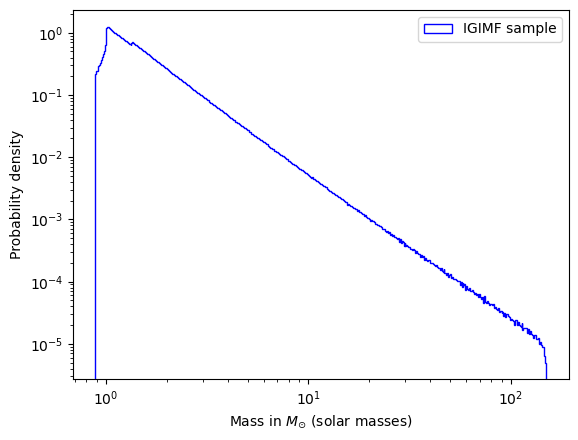

In [5]:
## This file contains an IGIMF sample cut off at 1 solar mass. 
## It resembles star formation in the Large Magellanic Cloud assuming a SFR 0f 0.4 solar masses/yr, an ECMF slope of beta=2 and a metallicity of [Z]=-0.37
data=np.loadtxt('Test_IGIMF_Mtot_4e6_beta_2_all_1SM_stars.txt')

logbins1=np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), int(2*len(data)**(2/5)))

plt.hist(data, bins=logbins1, density=True, histtype='step', color='blue', label='IGIMF sample')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Mass in $M_{\odot}$ (solar masses)')
plt.ylabel('Probability density')
plt.legend()

It is evident, that there are more lower-mass stars than massive stars within the sample and the high-mass end of the distribution shows a rapid downturn.\
We now want to model a function on this sample, using the previously defined MLEs.

If you know something about IGIMFs, you may notice that there are essentially no stars less massive than $1\,M_{\odot}$ within the sample.\
The lower end of the here used IGIMF sample was cut off for this example for the purpose of simplicity. This means the sample is only complete for stellar masses $>1\,M_{\odot}$.

### Performing MLE fits on the data

There are: 872583 datapoints
The sample for m>1 solar mass spans from 1.0000000507307043 solar masses to 149.4235017797271 solar masses
The sample for m>15 solar mass spans from 15.000137057834696 solar masses to 149.4235017797271 solar masses
The power law fit for the data with a cut at 1.0 is: 2.395522837551379 +- 0.000977655170973786
Schechter fit for m>1 solar mass:
The solution converged.
The fit parameters for the Schechter MLE are: alpha = 2.3954682132048792 M_turn = 122836.65499234585
The error estimates for alpha and M_turn are: alpha_error = 0.0009762366468276288 M_turn_error = 13474.077281620466
Modified Schechter fit for m>1 solar mass:
The solution converged.
The fit parameters for the modified Schechter MLE are: alpha = 2.3954454233106683 M_turn = 150.19740236480337 gamma = 85.58988169580537
The error estimates for alpha, M_turn and gamma are: alpha_error = 0.0015645091868052266 M_turn_error = 2.3024593217747866 gamma_error = 89.47732612143788
The power law fit for the da

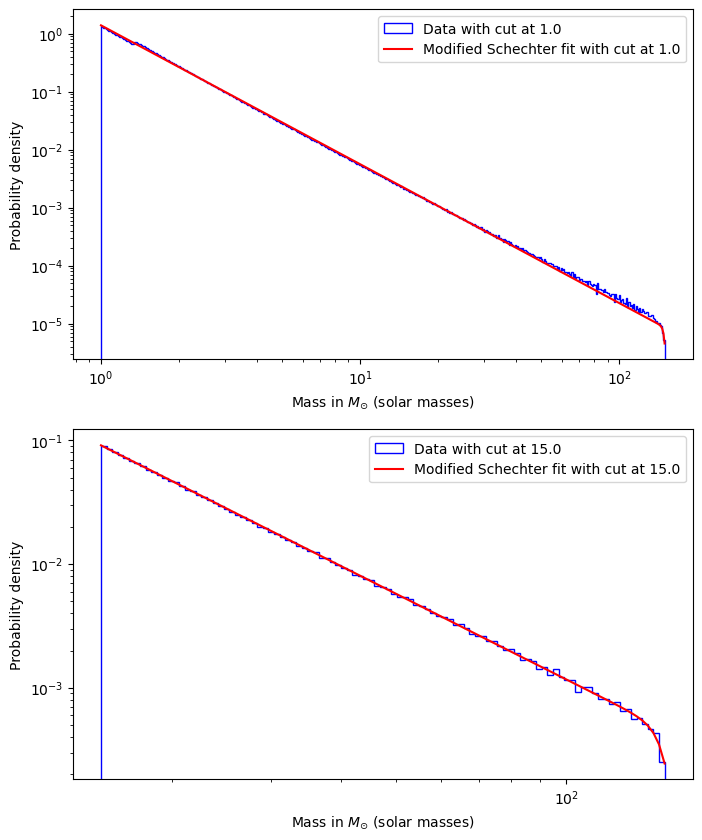

In [6]:
### making powerlaw fits of the data

print('There are:',len(data), 'datapoints')

cut1=1.0
cut2=15.0

data_cut1=data[data>cut1]
data_cut2=data[data>cut2]

print('The sample for m>1 solar mass spans from',np.min(data_cut1),'solar masses to', np.max(data_cut1), 'solar masses')
print('The sample for m>15 solar mass spans from',np.min(data_cut2),'solar masses to', np.max(data_cut2), 'solar masses')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,10))
logbins1=np.logspace(np.log10(np.min(data_cut1)), np.log10(np.max(data_cut1)), int(2*len(data_cut1)**(2/5)))
logbins2=np.logspace(np.log10(np.min(data_cut2)), np.log10(np.max(data_cut2)), int(2*len(data_cut2)**(2/5)))

## make MLE fits to the data for all masses larger than 1.0 solar masses

### make fit using power law MLE
slope1, std1=MLE_with_SE(data_cut1)
print('The power law fit for the data with a cut at 1.0 is:', slope1, '+-', std1)
Log_L_powerlaw1=Log_likelihood_powerlaw(data_cut1, slope1)
## Plot the power law fit
#ax1.plot(logbins1, Likelihood_normalization_powerlaw(data_cut1, slope1)*logbins1**(-slope1), color='green', label='Power law fit with cut at 1.0')
### make fit using Schechter MLE
print('Schechter fit for m>1 solar mass:')
alpha1, alpha_error1, M_turn1, M_turn_error1=MLE_Schechter_with_SE(data_cut1, 1.93, 87192.0)
Log_L_Schechter1=Log_likelihood_Schechter(data_cut1, alpha1, M_turn1, Likelihood_normalization_Schechter(np.min(data_cut1), np.max(data_cut1), alpha1, M_turn1))
## Plot the Schechter fit
#ax1.plot(logbins1, Likelihood_normalization_Schechter(np.min(data_cut1), np.max(data_cut1), slope1, M_turn1)*logbins1**(-slope1)*np.exp(-(logbins1/M_turn1)), color='black', label='Schechter fit with cut at 1.0')
### make fit using the modified Schechter MLE:
print('Modified Schechter fit for m>1 solar mass:')
slope1, slope_error1, M_turn1, M_turn_error1, gamma1, gamma_error1=MLE_modified_Schechter_with_SE(data_cut1, 2.35, 147.0, 25.0)
Log_L_modified_Schechter1=Log_likelihood_modified_Schechter(data_cut1, slope1, M_turn1, gamma1, Likelihood_normalization_modified_Schechter(np.min(data_cut1), np.max(data_cut1), slope1, M_turn1, gamma1))

## make MLE fits to the data for all masses larger than 15.0 solar masses

### make fit using power law MLE
slope2, std2=MLE_with_SE(data_cut2)
print('The power law fit for the data with a cut at 15.0 is:', slope2, '+-', std2)
Log_L_powerlaw2=Log_likelihood_powerlaw(data_cut2, slope2)
## Plot the power law fit
#ax2.plot(logbins2, Likelihood_normalization_powerlaw(data_cut2, slope2)*logbins2**(-slope2), color='green', label='Power law fit with cut at 15.0')
### make fit using Schechter MLE
print('Schechter fit for m>15 solar mass:')
alpha2, alpha_error2, M_turn2, M_turn_error2=MLE_Schechter_with_SE(data_cut2, 2.2, 87650.0)
Log_L_Schechter2=Log_likelihood_Schechter(data_cut2, alpha2, M_turn2, Likelihood_normalization_Schechter(np.min(data_cut2), np.max(data_cut2), alpha2, M_turn2))
## Plot the Schechter fit
#ax2.plot(logbins2, Likelihood_normalization_Schechter(np.min(data_cut2), np.max(data_cut2), slope2, M_turn2)*logbins2**(-slope2)*np.exp(-(logbins2/M_turn2)), color='black', label='Schechter fit with cut at 15.0')
### make fit using modified Schechter MLE:
print('Modified Schechter fit for m>15 solar mass:')
slope2, slope_error2, M_turn2, M_turn_error2, gamma2, gamma_error2=MLE_modified_Schechter_with_SE(data_cut2, 2.3, 150.0, 15.0)
Log_L_modified_Schechter2=Log_likelihood_modified_Schechter(data_cut2, slope2, M_turn2, gamma2, Likelihood_normalization_modified_Schechter(np.min(data_cut2), np.max(data_cut2), slope2, M_turn2, gamma2))


## Plot the modified Schechter MLE fits

ax1.hist(data_cut1, bins=logbins1, density=True, histtype='step', color='blue', label='Data with cut at 1.0')
ax1.plot(logbins1, Likelihood_normalization_modified_Schechter(np.min(data_cut1), np.max(data_cut1), slope1, M_turn1, gamma1)*logbins1**(-slope1)*np.exp(-(logbins1/M_turn1)**gamma1), color='red', label='Modified Schechter fit with cut at 1.0')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'Mass in $M_{\odot}$ (solar masses)')
ax1.set_ylabel('Probability density')
ax1.legend()


ax2.hist(data_cut2, bins=logbins2, density=True, histtype='step', color='blue', label='Data with cut at 15.0')
ax2.plot(logbins2, Likelihood_normalization_modified_Schechter(np.min(data_cut2), np.max(data_cut2), slope2, M_turn2, gamma2)*logbins2**(-slope2)*np.exp(-(logbins2/M_turn2)**gamma2), color='red', label='Modified Schechter fit with cut at 15.0')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'Mass in $M_{\odot}$ (solar masses)')
ax2.set_ylabel('Probability density')
ax2.legend()

print('The log likelihoods for the power law fits are:', Log_L_powerlaw1, 'for m>1 Msolar and', Log_L_powerlaw2, 'for m>15 Msolar')
print('The log likelihoods for the Schechter fits are:', Log_L_Schechter1, 'for m>1 Msolar and', Log_L_Schechter2, 'for m>15 Msolar')
print('The log likelihoods for the modified Schechter fits are:', Log_L_modified_Schechter1, 'for m>1 Msolar and', Log_L_modified_Schechter2, 'for m>15 Msolar')

The  modified Schechter MLE fits are plotted here to show that they can well reproduce the downturn of the IGIMF.\
The other fits can also be plotted for comparison, but are currently commented out.

Note that the IGIMF does NOT follow a pure power law form over the whole mass range.\
The fit results for the $m>1\,M_{\odot}$ sample differ to the fit results of the $m>15\,M_{\odot}$ sample.

### Important Note

The Schechter and modified Schechter **(MS)** codes need a first guess for the parameter values as input for their root-solving. So when you use them for your own data samples, keep in mind that you have to give initial guesses as input to them. The root-finding can be quite sensitive to the input. 

Also, it is very important that the root-solving return for the Schechter and MS MLE is: "The solution converged".\
Otherwise, you haven't found the (probably) best solution.

### Troubleshooting (Tips what to do for other return messages):

- "The number of calls to function has reached maxfev = 800"

You are on a good track. Usually entering the current best-fit values helps. Occurs often, if a way larger Mturn than currently used is needed (factor 2 or higher).

- "The iteration is not making good progress, as measured by the improvement from the last ten iterations"

One of your parameters makes you get stuck. It can help to vary them.\
For sharp downturns a larger gamma is helpful (gamma > 5 up to max 50), but only small adjustments of its value are usually needed (e.g. +5).\
For the Schechter function, a very large number for the Mturn is sometimes needed and the used one may be too small. Also, check if your alpha (the slope) is good, by comparing it with the estimate from the PL MLE.\
Look at what the plotted fit function does. It can help you get a feeling, what may go wrong.

### Finding the best-fit model

To infer which model fits best, without overfitting, one may use the **likelihood-ratio test**, which compares the determined log-likelihoods of the MLEs best-fit models.

### Likelihood-ratio test

Apart from the model parameters, also the log-likelihoods were determined for each model. \
One can use those to perform a likelihood-ratio test in order to determine whether adding additional model parameters increases the fit quality significantly enough to choose an advanced model over a simpler one. \
For example, one can test if the increase in fit quality, which is tracked by the log-likelihood, for the Schechter function fit compared to the pure power law fit is significant enough to prefer the Schechter fit over the pure power law fit.\
This is explained in more detail in the supplementary document.

To perform a likelihood-ratio test, the following code can be used:\
(This code was taken from Stack Overflow and can be found under this [link](https://stackoverflow.com/questions/38248595/likelihood-ratio-test-in-python))

Lambda: 0.016313177708070725
p-value: 0.8983681475862996


Text(0.5, 1.0, 'χ2(1) distribution')

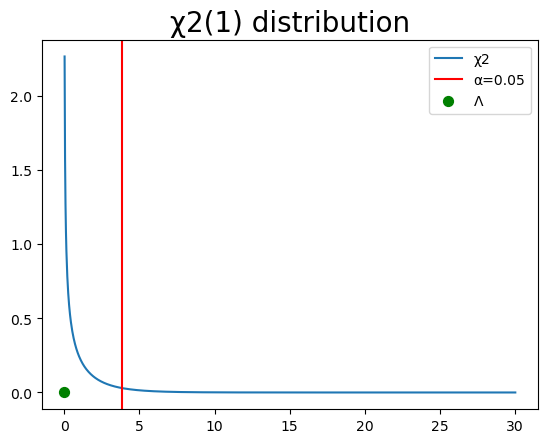

In [7]:
## log likelihoods for the different data sets (m>1.0 and m>15.0 Msolar)
## for the powerlaw, Schechter and MS fits
## Log_Li_j means the log likelihood for the i-th fit and j-th data set 
## (i=1,2,3 for powerlaw, Schechter and MS fits respectively; j=1,2 for data sets with cut at 1.0 and 15.0 Msolar respectively)
## df below is the number of degree of freedom difference between the models
## If you want to compare PL to Schechter fit, use df=1
## If you want to compare Schechter to MS fit, use df=1
## If you want to compare PL to MS fit, use df=2

Log_L0_1=Log_L_powerlaw1
Log_L0_2=Log_L_powerlaw2
Log_L1_1=Log_L_Schechter1
Log_L1_2=Log_L_Schechter2
Log_L2_1=Log_L_modified_Schechter1
Log_L2_2=Log_L_modified_Schechter2

## Comparing the performance of model fit between Schechter fit (L1) and power law fit (L0) for m>15 solar masses (_2) 
Lambda = 2*(Log_L1_2-Log_L0_2) ## Lambda is the metric that tracks the difference in likelihoods
print('Lambda:',Lambda)

from scipy.stats import chi2

df = 1 ## difference in the number of parameters between the two models (difference in degrees of freedom) 
## compute the p-value of the likelihood ratio test
pvalue= 1-chi2(df).cdf(Lambda)
print('p-value:',pvalue)

α, df = 0.05, 1
x = np.linspace(0, 30, 1000)
plt.plot(x, chi2(df).pdf(x), label='χ2')
plt.axvline(chi2(df).ppf(1-α), color='red', label='α=0.05')
plt.scatter(Lambda, 0, color='green', s=50, label='Λ')
plt.legend()
plt.title('χ2({}) distribution'.format(df), size=20)

It determines the significance $\Lambda$ and calculates the corresponding p-value. Here, an $\alpha$ of 0.05 is chosen as significance level. If our p-value is less than $\alpha=0.05$, the advanced model provides a significant fit improvement and the advanced model is chosen over the simple model. A p-value of $< 0.05$ means that there is a less than 5% random chance that the improvement in fit is due to statistical noise.

In our example, the p-value is about 0.9, which means that the betterment is not significant.

#### Likelihood ratio test between PL and MS MLE

Lambda: 7.222701894294005
p-value: 0.027015325925490052


Text(0.5, 1.0, 'χ2(2) distribution')

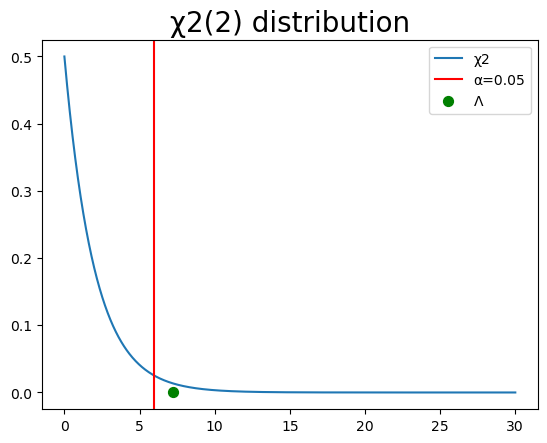

In [8]:
## Comparing the performance of model fit between MS fit (L2) and power law fit (L0) for m>15 solar masses (_2)
Lambda = 2*(Log_L2_2-Log_L0_2) ## Lambda is the metric that tracks the difference in likelihoods
print('Lambda:',Lambda)

from scipy.stats import chi2

## Changed df to 2
df = 2 ## difference in the number of parameters between the two models (difference in degrees of freedom) 
## compute the p-value of the likelihood ratio test
pvalue= 1-chi2(df).cdf(Lambda)
print('p-value:',pvalue)

## Changed df to 2
α, df = 0.05, 2
x = np.linspace(0, 30, 1000)
plt.plot(x, chi2(df).pdf(x), label='χ2')
plt.axvline(chi2(df).ppf(1-α), color='red', label='α=0.05')
plt.scatter(Lambda, 0, color='green', s=50, label='Λ')
plt.legend()
plt.title('χ2({}) distribution'.format(df), size=20)

In this case, the betterment is significant, as the p-value is < 0.05.\
Therefore using a MS function gives a better fit to the data then the pure power law, given our significance level $\alpha$.

Generally, if the green point is to the right of the red line, the betterment is significant. If not, it is not.

### A short note on using hypothesis tests on optimally sampled data
Whether it makes sense to use hypothesis tests, such as the likelihood-ratio test, on composite optimally sampled data sets, such as the here used IGIMF sample, is debatable.\
This is also shortly discussed in the supplementary document.